<a href="https://colab.research.google.com/github/noobylub/Computational-Linguistic/blob/master/lecture_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Corpus Linguistics, Week 7**

This week, we will consider the concept of text-level variables. We exemplify with a measure of formality. Then we re-think the problem more generally in terms of features, dimensionality and clustering.

**Part 1:** Get the frequency of some text-level features.<br>

Upload the four texts:<br>
HP1 - first chapter of Harry Potter<br>
LR1 - first chapter of Lord of the Rings<br>
NaC - a recent article from Nature Chemistry<br>
JoC - a recent article from the Journal of Chemistry<br>

In [2]:
# Upload the four files

from google.colab import files

four_files = files.upload()

Saving NaC.txt to NaC.txt
Saving LR1.txt to LR1.txt
Saving JoC.txt to JoC.txt
Saving HP1.txt to HP1.txt


**Exercise:**

We want to operationalise the difference between two genres: fictional fantasy narrative vs. academic research paper. Propose some text-level features that could be helpful for this task?

---

Idea 1:<br>
Idea 2:<br>
Idea 3:

In [6]:
# First feature:

first_second_pers = ["i", "you", "me", "my", "your", "mine", "yours"]
first_second_count = []   # We'll count the number of occurrences of these words here.

third_pers = ["he", "she", "it", "him", "her", "his", "her", "its"]
third_count = []   # We'll count the number of occurrences of the third person pronouns here.

filename_list = []  # I store here the files in the sequence as I process them

word_count = []  # Here, I store the number of words in each text

for filename in four_files:
  filename_list.append(filename)
  with open(filename, 'r', encoding='utf-8') as file:
    raw_text = file.read()
    raw_text_list = raw_text.split()
    # ["The", "text", "now", "looks", "like", "this"]
    word_count.append(len(raw_text_list))
    # initialise a counter for the 1st/2nd person vs. 3rd person words
    i = 1
    j = 1
    for current_word in raw_text_list:
      if current_word.lower() in first_second_pers:
        i+=1
      if current_word.lower() in third_pers:
        j+=1
    first_second_count.append(i)
    third_count.append(j)

# print(filename_list)
# print("Total word count",word_count)
# print("First second count",first_second_count)
# print("Third person count",third_count)
# fst_ratio = [third_count[i] / first_second_count[i] for i in range(4)]
# print(fst_ratio)

for index,file_name in enumerate(filename_list):
  print("File Name:", file_name)
  print("Word Count:", word_count[index])
  print("Third Person Count:", third_count[index])
  print("First Second Count:", first_second_count[index])
  print("Ratio:", fst_ratio[index])
  print()



File Name: NaC.txt
Word Count: 6867
Third Person Count: 39
First Second Count: 1
Ratio: 39.0

File Name: LR1.txt
Word Count: 9852
Third Person Count: 445
First Second Count: 344
Ratio: 1.2936046511627908

File Name: JoC.txt
Word Count: 6323
Third Person Count: 13
First Second Count: 1
Ratio: 13.0

File Name: HP1.txt
Word Count: 4651
Third Person Count: 323
First Second Count: 63
Ratio: 5.126984126984127



In [7]:
# import spacy
# will take about 1min (40 seconds)

import spacy


# Download the English model you want to use
!python -m spacy download en_core_web_lg

# initialise spacy nlp pipeline

nlp = spacy.load('en_core_web_lg')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.7/400.7 MB 1.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
# Second, third feature feature:

past_count = []  # store the number of past tense verbs
pres_count = [] # store the number of present tense verbs

sent_length = [] # store the sentence length here

for filename in four_files:
  with open(filename, 'r', encoding='utf-8') as file:
    print("Now processing", filename)
    raw_text = file.read()
    # POS-tag the file
    processed_text = nlp(raw_text)

    # remember that processed_text has .sent, .tag_, .text
    sent_length.append(len(list(processed_text.sents)))

    # initialise a counter for the past vs. pres tense words
    i = 1
    j = 1
    for word in processed_text:
      if word.tag_ == "VBD":
        i+=1
      if word.tag_ in ["VBP", "VBZ"]:
        j+=1
    past_count.append(i)
    pres_count.append(j)

print(filename_list)
print(past_count)
print(pres_count)


# ratio of past to present tense
past_ratio = [past_count[i] / pres_count[i]  for i in range(4)]
print(past_ratio)

print(sent_length)

# how many words per sentence on averge
sent_ratio = [word_count[i] / sent_length[i]  for i in range(4)]
print(sent_ratio)


In [ ]:
# https://pypi.org/project/syllapy/

!pip install syllapy
import syllapy

# to randomly present words later (random_sample)
import random



In [ ]:
syllapy.count("beautiful")  # 3

In [ ]:
# Feature number 3

long_words = []  # store number of long words for each text file here
all_words = [] # to randomly show a few examples

for filename in four_files:
  with open(filename, 'r', encoding='utf-8') as file:
    print("Now processing", filename)
    raw_text = file.read()
    raw_text_list = raw_text.split()
    # ["The", "text", "now", "looks", "like", "this"]
    i=1
    for word in raw_text_list:
      if syllapy.count(word) > 4:
        all_words.append(word)
        i+=1
    long_words.append(i)

print(long_words)

random.sample(all_words, 5)

# how many long words relative to sentence length
lw_ratio = [word_count[i] / long_words[i]  for i in range(4)]
print(lw_ratio)


In [ ]:
# Store relevant data in spreadsheet, pandas

import pandas as pd

# Each row = one text file
# Each column = one text-leve feature

data = {
    'filename': filename_list,
    'fstr': fst_ratio,    # ratio of first/second to third person pronouns (how often do you see "I" and "you")
    'past': past_ratio,   # how many more times do you see past tense than present tense
    'sent': sent_ratio,   # how many words per sentence
    'long': lw_ratio,     # how many words till you find a 4-syllable word
    # etc.
}

df = pd.DataFrame(data)

print(df)


Example plot<br>
You do not need to understand plotting in pything with matplotlib, the below is just an illustration.

In [ ]:


import matplotlib.pyplot as plt
import numpy as np

# Define order
order = ['HP1.txt', 'LR1.txt', 'NaC.txt', 'JoC.txt']
df_ordered = df.set_index('filename').loc[order].reset_index()

fig, ax1 = plt.subplots(figsize=(14, 5))

x = np.arange(len(order))
width = 0.2

# First bars (fstr) - left y-axis
bars1 = ax1.bar(x - 1.5*width, df_ordered['fstr'], width, label='1st/2nd person', color='steelblue')
ax1.set_ylabel('fstr', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

# Second y-axis (right side)
ax2 = ax1.twinx()
bars2 = ax2.bar(x - 0.5*width, df_ordered['past'], width, label='Past tense', color='darkorange')
ax2.set_ylabel('past', color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')

# Third y-axis (left side, offset outward)
ax3 = ax1.twinx()
ax3.spines['left'].set_position(('outward', 60))
ax3.yaxis.set_label_position('left')
ax3.yaxis.tick_left()
bars3 = ax3.bar(x + 0.5*width, df_ordered['sent'], width, label='Sent length', color='seagreen')
ax3.set_ylabel('sent', color='seagreen')
ax3.tick_params(axis='y', labelcolor='seagreen')

# Fourth y-axis (right side, offset outward)
ax4 = ax1.twinx()
ax4.spines['right'].set_position(('outward', 60))
bars4 = ax4.bar(x + 1.5*width, df_ordered['long'], width, label='Long words', color='crimson')
ax4.set_ylabel('long', color='crimson')
ax4.tick_params(axis='y', labelcolor='crimson')

# X-axis labels
ax1.set_xticks(x)
ax1.set_xticklabels(order)

# Legend
fig.legend(loc='upper right', bbox_to_anchor=(0.85, 0.88))

plt.title('Text-level features of four texts')
plt.tight_layout()
plt.show()

Note to self: Run below, then go to section 4 of the lecture slides. Takes about 3mins...

**Part 2:** Calculating Heylighen and Dewaele's (2002) Formality-score.

In [8]:
# You can use spaCy to POS-tag your own texts for the calculation.
# I will use some texts from COCA, which is already POS-tagged.
# Find the COCA corpus files on Canvas.
# We will use a subset of the texts for 2012 separated by genres: (1) academic writing, (2) fiction, (3) magazines, (4) news, and (5) spoken TV interviews

from google.colab import files
uploaded = files.upload()  # Upload the single zip file



Saving COCA2012.zip to COCA2012.zip


In [9]:
!unzip COCA2012.zip

Archive:  COCA2012.zip
  inflating: wlp_spok_2012.txt       
  inflating: wlp_acad_2012.txt       
  inflating: wlp_fic_2012.txt        
  inflating: wlp_mag_2012.txt        
  inflating: wlp_news_2012.txt       


A typical COCA file looks like this:<br>
`##4119509		`<br>
`acm		vv0_nn1`<br>
`s	s	zz1`<br>
`annual	annual	jj`<br>
`report	report	nn1`<br>
`for	for	if`<br>
`fY11		fo`<br>
`aCM	acm	jj_nn1_vv0`<br>
`membership	membership	nn1`<br>
`reached	reach	vvd_vvn`<br>

With the first column the word form, the second column the lemma, and the third column the POS tag. For the POS-tags see <a href="https://ucrel.lancs.ac.uk/claws7tags.html">here</a>. New texts start after \#\#.

In [10]:
# I also upload the documentation for the corpus
# called "coca sources.txt"

uploaded_doc_file = files.upload()

Saving coca-sources.txt to coca-sources.txt


In [11]:
# Read the COCA documentation file
# I used encoding='utf-8', but this created an error. There are special characters in the file (cliché, Schrödinger,...) that are not encoded for UTF-8 correctly.
# I use latin-1 instead. This is fine here as I'm not going to use the text titles as linguistic features.
# You can try such an approach when you create the "help" dataset and face similar encoding issues.

with open('coca-sources.txt', 'r', encoding='latin-1') as file:
    coca_doc = file.read()

# Look at the first few lines of the document
first_few_lines = coca_doc.split('\n')[:20]
for line in first_few_lines:
    print(line)

textID	year	genre	subGenre	source	title
-----	-----	-----	-----	-----	-----
96	2001	SPOK	105	Fox_Hume	Interview With Byron York
97	2001	SPOK	105	Fox_Hume	Political Headlines
98	2001	SPOK	105	Fox_Hume	Special Report Roundtable
198	2001	SPOK	105	Fox_OReilly	Impact: Is the Economy Heading Into a Recession?
199	2001	SPOK	105	Fox_OReilly	Personal Story: Mayor Jerry Brown
298	2001	SPOK	105	Fox_OReilly	Governor Jeb Bush Criticized for School Admissions Program
299	2001	SPOK	105	Fox_OReilly	Will President Bush Get His Budget Through Congress?
398	2001	SPOK	105	Fox_OReilly	Flashback: Jesse Jackson''s Finances
399	2001	SPOK	105	Fox_OReilly	Is Bullying to Blame for Some School Shootings?
498	2001	SPOK	105	Fox_OReilly	"Boston" Magazine: Sheriff Tom Hodgson Toughest in Bay State
499	2001	SPOK	105	Fox_OReilly	Government Blunders: Low Bail Leads to Murders
597	2001	SPOK	105	Fox_OReilly	Impact: Should Schools be Named for Slaveowners?
598	2001	SPOK	105	Fox_OReilly	Unresolved Problem: Pregnant Couple S

When I find the symbol \#\# in a coca text file, I want to look up the textID, title, and genre in the documentaiton file, and record the occurrence of the POS tags for the calculations for the Formality-score for that text.

In [12]:
# Store POS counts for each text
# We'll use a dictionary so that we can store nouns, verbs, adjectives etc. separately
# this dictionary will in the end contain all our counts / data for the calculation

text_pos_counts = {}

# Create a text ID variable and at first there is no text ID
current_text_id = None

# Read in the entire file as a string
with open('wlp_acad_2012.txt', 'r', encoding='utf-8') as file:
    acad = file.read()

# We'll loop through the text, line by line:

i = 0
for line in acad.split('\n'):
  print(line)
  i += 1
  if i > 20:
    break




##4119509		
acm		vv0_nn1
s	s	zz1
annual	annual	jj
report	report	nn1
for	for	if
fY11		fo
aCM	acm	jj_nn1_vv0
membership	membership	nn1
reached	reach	vvd_vvn
another	another	dd1
all-time	all-time	jj
high	high	jj
for	for	if
the	the	at
ninth	ninth	md
consecutive	consecutive	jj
year	year	nnt1
and	and	cc
much	much	da1
of	of	io


In [18]:
i = 0

# Go through every line in the acad text string
for line in acad.split("\n"):
  # Check if this line indicates a new text section
  if line.startswith('##'):
    # When you see ##, you know a new text starts here
    current_text_id = line.replace('##', '').strip()
    # Look up the title of this text id in the corpus documentation
    # Set title to "Unknown" as a default value in case no matching text ID is found in the documentation
    title = "Unknown"
    # Go through every line in the documentation
    # Documentation looks like this:
    # textID	year	genre	subGenre	source	title
    # -----	-----	-----	-----	-----	-----
    # 96	2001	SPOK	105	Fox_Hume	Interview With Byron York
    # 97	2001	SPOK	105	Fox_Hume	Political Headlines
    # 98	2001	SPOK	105	Fox_Hume	Special Report Roundtable
    for doc_line in coca_doc.split('\n'):
        # Split the line by tab character
        doc_parts = doc_line.split("\t")
        # The text ID is listed in the first column
        if doc_parts[0] == current_text_id:
          # If you found the text ID, then the title should be in the 6th column
          title = doc_parts[5]
          break
    print("Found a new text. The title of this text is:", title)


    # Initialise pos counts for this text
    text_pos_counts[current_text_id] = { 'title;': title,
                    'nouns': 0, 'adjs': 0, 'preps': 0, 'arts': 0,
                    'prns': 0, 'verbs': 0, 'advs': 0, 'ints': 0
                }
  # Otherwise, if the line does not start with ##, this is not a line that indicates a new text
  # So it must be a "normal" three-column line with word, lemma, pos
  else:
    parts = line.split("\t")
  # Then we'll continue through every line ...
  # Split the line into parts
    print(parts)

  i += 1
  if i > 20:
    break

Found a new text. The title of this text is: ACM's Annual Report. 
['acm', '', 'vv0_nn1']
['s', 's', 'zz1']
['annual', 'annual', 'jj']
['report', 'report', 'nn1']
['for', 'for', 'if']
['fY11', '', 'fo']
['aCM', 'acm', 'jj_nn1_vv0']
['membership', 'membership', 'nn1']
['reached', 'reach', 'vvd_vvn']
['another', 'another', 'dd1']
['all-time', 'all-time', 'jj']
['high', 'high', 'jj']
['for', 'for', 'if']
['the', 'the', 'at']
['ninth', 'ninth', 'md']
['consecutive', 'consecutive', 'jj']
['year', 'year', 'nnt1']
['and', 'and', 'cc']
['much', 'much', 'da1']
['of', 'of', 'io']


---

**Exercise**: We now need to decide which of the many POS-tags fall into the categories Heylighen and Dewaele's (2002) categories. Open the file wlp_acad_2012.txt, go through it and fill in the 8 categories accordingly. Use regex where appropriate to simplify the task.

In [19]:
# https://ucrel.lancs.ac.uk/claws7tags.html


# categories indicating formality
nouns = ['nn.*',  "np.*"]
adjs = ["jj", "jjr", "jjt", "jk"]
preps = ["ii", "if", "io", "iw"]
arts = ["at.*"]

# categories indicating informality
prns = ["pph.*", "ppi.*"]
verbs = ["v.*"]
advs = ["ra", "rr", "rrr", "rrt"]
ints = ['uh']

---

In [20]:
import re
i = 0

for line in acad.split("\n"):

  ################################################### (see above for explanation of code below)

  if line.startswith('##'):
    current_text_id = line.replace('##', '').strip()
    title = "Unknown"
    for doc_line in coca_doc.split('\n'):
        doc_parts = doc_line.split("\t")
        if doc_parts[0] == current_text_id:
          title = doc_parts[5]
          break
    print("Found a new text. The title of this text is:", title)
    text_pos_counts[current_text_id] = { 'title;': title,
                    'nouns': 0, 'adjs': 0, 'preps': 0, 'arts': 0,
                    'prns': 0, 'verbs': 0, 'advs': 0, 'ints': 0
                }
    print(text_pos_counts)
  ###################################################

  else:
    parts = line.split("\t")

    # Make sure we have enough parts and we're in a current text section
    if len(parts) >= 3 and current_text_id is not None:
      # the third column of the line will include the POS tag
      pos_tag = parts[2]
      print("\npos tag is now", pos_tag)

      # Now check each category
      # Nouns
      for pattern in nouns:
          if re.match(pattern, pos_tag):
              text_pos_counts[current_text_id]['nouns'] += 1
              break

      # Adjectives
      for pattern in adjs:
          if re.match(pattern, pos_tag):
              text_pos_counts[current_text_id]['adjs'] += 1
              break

      # Prepositions
      for pattern in preps:
          if re.match(pattern, pos_tag):
              text_pos_counts[current_text_id]['preps'] += 1
              break

      # Articles
      for pattern in arts:
          if re.match(pattern, pos_tag):
              text_pos_counts[current_text_id]['arts'] += 1
              break

      # Pronouns
      for pattern in prns:
          if re.match(pattern, pos_tag):
              text_pos_counts[current_text_id]['prns'] += 1
              break

      # Verbs
      for pattern in verbs:
          if re.match(pattern, pos_tag):
              text_pos_counts[current_text_id]['verbs'] += 1
              break

      # Adverbs
      for pattern in advs:
          if re.match(pattern, pos_tag):
              text_pos_counts[current_text_id]['advs'] += 1
              break

      # Interjections
      for pattern in ints:
          if re.match(pattern, pos_tag):
              text_pos_counts[current_text_id]['ints'] += 1
              break

  # Illustrate functionality
  print(parts)
  print(text_pos_counts)
  i += 1
  if i > 10:
    break


Found a new text. The title of this text is: ACM's Annual Report. 
{'4119509': {'title;': "ACM's Annual Report. ", 'nouns': 0, 'adjs': 0, 'preps': 0, 'arts': 0, 'prns': 0, 'verbs': 0, 'advs': 0, 'ints': 0}}
['of', 'of', 'io']
{'4119509': {'title;': "ACM's Annual Report. ", 'nouns': 0, 'adjs': 0, 'preps': 0, 'arts': 0, 'prns': 0, 'verbs': 0, 'advs': 0, 'ints': 0}}

pos tag is now vv0_nn1
['acm', '', 'vv0_nn1']
{'4119509': {'title;': "ACM's Annual Report. ", 'nouns': 0, 'adjs': 0, 'preps': 0, 'arts': 0, 'prns': 0, 'verbs': 1, 'advs': 0, 'ints': 0}}

pos tag is now zz1
['s', 's', 'zz1']
{'4119509': {'title;': "ACM's Annual Report. ", 'nouns': 0, 'adjs': 0, 'preps': 0, 'arts': 0, 'prns': 0, 'verbs': 1, 'advs': 0, 'ints': 0}}

pos tag is now jj
['annual', 'annual', 'jj']
{'4119509': {'title;': "ACM's Annual Report. ", 'nouns': 0, 'adjs': 1, 'preps': 0, 'arts': 0, 'prns': 0, 'verbs': 1, 'advs': 0, 'ints': 0}}

pos tag is now nn1
['report', 'report', 'nn1']
{'4119509': {'title;': "ACM's Annua

Next, we must keep track of the total number of words in the current text file. We simply add "total" to our text_pos_counts dictionary and increment this counter by one whenever we process a new tag.<br>
However, the text files contain strings of @ characters for copy right reasons. We want to exclude those from the counter. For example:<br>
`computer	computer	nn1` <br>
`@		ii`<br>
`@		ii`<br>
`@		ii`<br>
`@		ii`<br>
`@		ii`<br>
`@		ii`<br>
`@		ii`<br>
`@		ii`<br>
`@		ii`<br>
`@		ii`<br>
`presence	presence	nn1`<br> This sequence is always ten words long and occurs every 400 words, resulting in an unavoidable loss of 2.5% of the textual data. Most importantly, we do not want those to count towards prepositions.<br>
Furthermore, we want to exclude punctuation marks. Punctuation signs have the POS tag y. For instance:<br>
`ready	ready	jj_rr@`<br>
`.	.	y`<br>
`"	"	y`<br>
`Was	be	vbdz`

Note to myself: Run this once, then immediately run the next code. Then explain this.

In [21]:
import re
i = 0
line_counter = 0  # This is just to illustrate the functionality of the word counting

for line in acad.split("\n"):
  line_counter += 1

  ################################################### (see above for explanation of code below)

  if line.startswith('##'):
    current_text_id = line.replace('##', '').strip()
    title = "Unknown"
    for doc_line in coca_doc.split('\n'):
        doc_parts = doc_line.split("\t")
        if doc_parts[0] == current_text_id:
          title = doc_parts[5]
          break
    print("Found a new text. The title of this text is:", title)
    text_pos_counts[current_text_id] = { 'title;': title,
                    'nouns': 0, 'adjs': 0, 'preps': 0, 'arts': 0,
                    'prns': 0, 'verbs': 0, 'advs': 0, 'ints': 0,
                    'total': 0   # here is the new addition, to calculate a percentage
                }   # add a "total" count!

  else:
    parts = line.split("\t")
    if len(parts) >= 3 and current_text_id is not None:
      pos_tag = parts[2]
      for pattern in nouns:
          if re.match(pattern, pos_tag):
              text_pos_counts[current_text_id]['nouns'] += 1
              text_pos_counts[current_text_id]['total'] += 1
              break
      for pattern in adjs:
          if re.match(pattern, pos_tag):
              text_pos_counts[current_text_id]['adjs'] += 1
              text_pos_counts[current_text_id]['total'] += 1
              break
      for pattern in preps:
          if re.match(pattern, pos_tag) and parts[0] != "@": # here I exclude @ ii from being counted as preposition / word
              text_pos_counts[current_text_id]['preps'] += 1
              text_pos_counts[current_text_id]['total'] += 1
              break
      for pattern in arts:
          if re.match(pattern, pos_tag):
              text_pos_counts[current_text_id]['arts'] += 1
              text_pos_counts[current_text_id]['total'] += 1
              break
      for pattern in prns:
          if re.match(pattern, pos_tag):
              text_pos_counts[current_text_id]['prns'] += 1
              text_pos_counts[current_text_id]['total'] += 1
              break
      for pattern in verbs:
          if re.match(pattern, pos_tag):
              text_pos_counts[current_text_id]['verbs'] += 1
              text_pos_counts[current_text_id]['total'] += 1
              break
      for pattern in advs:
          if re.match(pattern, pos_tag):
              text_pos_counts[current_text_id]['advs'] += 1
              text_pos_counts[current_text_id]['total'] += 1
              break
      for pattern in ints:
          if re.match(pattern, pos_tag):
              text_pos_counts[current_text_id]['ints'] += 1
              text_pos_counts[current_text_id]['total'] += 1
              break

  ##########################################################################


  # Illustrate functionality
  # Display the total for lines 170-220:
  if 185 <= line_counter <= 205 and current_text_id is not None:
    print(parts)
    print(f"Line {line_counter}: Total word count is now: {text_pos_counts[current_text_id]['total']}")

  i += 1
  if i > 300:
    break


Found a new text. The title of this text is: ACM's Annual Report. 
['promoting', 'promote', 'vvg']
Line 185: Total word count is now: 141
['the', 'the', 'at']
Line 186: Total word count is now: 142
['importance', 'importance', 'nn1']
Line 187: Total word count is now: 143
['of', 'of', 'io']
Line 188: Total word count is now: 144
['computer', 'computer', 'nn1']
Line 189: Total word count is now: 145
['@', '', 'ii']
Line 190: Total word count is now: 145
['@', '', 'ii']
Line 191: Total word count is now: 145
['@', '', 'ii']
Line 192: Total word count is now: 145
['@', '', 'ii']
Line 193: Total word count is now: 145
['@', '', 'ii']
Line 194: Total word count is now: 145
['@', '', 'ii']
Line 195: Total word count is now: 145
['@', '', 'ii']
Line 196: Total word count is now: 145
['@', '', 'ii']
Line 197: Total word count is now: 145
['@', '', 'ii']
Line 198: Total word count is now: 145
['@', '', 'ii']
Line 199: Total word count is now: 145
['presence', 'presence', 'nn1']
Line 200: Total 

In [23]:
# Now let's run the code on all the text files
# Add the genre for every file
# While this is running, complete the next exercises on the slides (time to execute the code for me: 14mins!)

# Define the list of COCA files to process
COCA_2012_files = [
    'wlp_acad_2012.txt',
    'wlp_fic_2012.txt',
    'wlp_mag_2012.txt',
    'wlp_news_2012.txt',
    'wlp_spok_2012.txt'
]

for COCA_file in COCA_2012_files:
  # I use encoding latin-1 because Fiction created an encoding problem. I'm only interested in the POS tags here, so that should be okay.
  with open(COCA_file, 'r', encoding='latin-1') as file:
    print(f"Now processing {COCA_file}\n\n")
    current_COCA_file = file.read()

  for line in current_COCA_file.split("\n"):

    if line.startswith('##'):
      current_text_id = line.replace('##', '').strip()
      title = "Unknown"
      for doc_line in coca_doc.split('\n'):
          doc_parts = doc_line.split("\t")
          if doc_parts[0] == current_text_id:
            title = doc_parts[5]
            # Add the genre to the text_pos_counts as well
            genre = doc_parts[2]
            if genre not in ['ACAD', 'SPOK', 'FIC', 'MAG', 'NEWS']:
              genre = 'OTHER'
              print(f"Could not find the genre for this text: {title}")
              break
            break

      text_pos_counts[current_text_id] = { 'title': title, 'genre': genre,
                      'nouns': 0, 'adjs': 0, 'preps': 0, 'arts': 0,
                      'prns': 0, 'verbs': 0, 'advs': 0, 'ints': 0,
                      'total': 0
                  }

    else:
      parts = line.split("\t")
      if len(parts) >= 3 and current_text_id is not None:
        pos_tag = parts[2]
        for pattern in nouns:
            if re.match(pattern, pos_tag):
                text_pos_counts[current_text_id]['nouns'] += 1
                break
        for pattern in adjs:
            if re.match(pattern, pos_tag):
                text_pos_counts[current_text_id]['adjs'] += 1
                break
        for pattern in preps:
            if re.match(pattern, pos_tag):
                text_pos_counts[current_text_id]['preps'] += 1
                break
        for pattern in arts:
            if re.match(pattern, pos_tag):
                text_pos_counts[current_text_id]['arts'] += 1
                break
        for pattern in prns:
            if re.match(pattern, pos_tag):
                text_pos_counts[current_text_id]['prns'] += 1
                break
        for pattern in verbs:
            if re.match(pattern, pos_tag):
                text_pos_counts[current_text_id]['verbs'] += 1
                break
        for pattern in advs:
            if re.match(pattern, pos_tag):
                text_pos_counts[current_text_id]['advs'] += 1
                break
        for pattern in ints:
            if re.match(pattern, pos_tag):
                text_pos_counts[current_text_id]['ints'] += 1
                break

        if pos_tag != 'y' and parts[0] != '@':
          text_pos_counts[current_text_id]['total'] += 1

Now processing wlp_acad_2012.txt


Now processing wlp_fic_2012.txt




KeyboardInterrupt: 

In [ ]:
print (str(text_pos_counts)[0:200])

In [ ]:
# Display the first 5 entries from the text_pos_counts dictionary
print("\nFirst 5 entries from the text_pos_counts dictionary:")
# remember that a dictionary has keys and values, so you write: for keys, values in dict.items():
for i, (text_id, counts) in enumerate(text_pos_counts.items()):
    if i >= 5:
        break
    print(f"\nText ID: {text_id}")
    print(f"Title: {counts['title']}")
    print(f"Genre: {counts['genre']}")
    print(f"Total words: {counts['total']}")
    # The notation *100:.2f is a Python formatting instruction that
    # multiplies the value by 100 (*100) and then
    # formats gives 2 decimal places to the resul(:.2f)
    print(f"Nouns: {counts['nouns']} ({counts['nouns']/counts['total']*100:.2f}%)")
    print(f"Adjectives: {counts['adjs']} ({counts['adjs']/counts['total']*100:.2f}%)")
    print(f"Prepositions: {counts['preps']} ({counts['preps']/counts['total']*100:.2f}%)")
    print(f"Articles: {counts['arts']} ({counts['arts']/counts['total']*100:.2f}%)")
    print(f"Pronouns: {counts['prns']} ({counts['prns']/counts['total']*100:.2f}%)")
    print(f"Verbs: {counts['verbs']} ({counts['verbs']/counts['total']*100:.2f}%)")
    print(f"Adverbs: {counts['advs']} ({counts['advs']/counts['total']*100:.2f}%)")
    print(f"Interjections: {counts['ints']} ({counts['ints']/counts['total']*100:.2f}%)")

In [ ]:
# We can now calculate the Formality-Score for each text.

# in order to plot this, I create a new dictionary with the genres
# then I will add to those the calculated Formliaty-scores for each text
genre_data = {'ACAD': [], 'FIC': [], 'MAG': [], 'NEWS': [], 'SPOK': [], 'OTHER': []}

# go through every text in the text_pos_counts dictionary:
for text_id, counts in text_pos_counts.items():
    # just in case something went wrong, we want to avoid division by zero
    if counts['total'] > 0:
        # Calculate the percentages for each POS category as in the example above
        noun_pct = counts['nouns'] / counts['total'] * 100
        adj_pct = counts['adjs'] / counts['total'] * 100
        prep_pct = counts['preps'] / counts['total'] * 100
        art_pct = counts['arts'] / counts['total'] * 100
        prn_pct = counts['prns'] / counts['total'] * 100
        verb_pct = counts['verbs'] / counts['total'] * 100
        adv_pct = counts['advs'] / counts['total'] * 100
        int_pct = counts['ints'] / counts['total'] * 100

        # Calculate F-score using Heylighen & Dewaele's formula
        Formality_Score = (noun_pct + adj_pct + prep_pct + art_pct -
                  prn_pct - verb_pct - adv_pct - int_pct + 100) / 2

        # Store the F-score in the dictionary
        counts['Formality_Score'] = Formality_Score

        # Add the Formality-Score to the genre_data for plotting
        # Find the genre for the current text ID
        genre = counts['genre']
        # If that genre exists in the genre_data (which it always should, hopefully there won't be any OTHER)
        if genre in genre_data:
          # then append the Formality-Score to the list of values for that genre
          genre_data[genre].append(Formality_Score)

In [ ]:
# Define genre order for x-axis
genre_order = ['MAG', 'FIC', 'SPOK', 'ACAD', 'NEWS']

In [ ]:
# (Click, then explain!)
# Now let's plot the results
# Visualisation of data is something planned to do in R later
# But just to illustrate...

import matplotlib.pyplot as plt
import random  # For jittering points

# Create scatterplot
plt.figure(figsize=(12, 8))

# Create numerical x-positions
x_positions = {}
for i, genre in enumerate(genre_order):
  x_positions[genre] = i
  # This will result in a dictionary like {'MAG': 0, 'FIC': 1, 'SPOK': 2, 'ACAD': 3, 'NEWS': 4}
  # Depending on how we specified the order of the genres above

# Define colors for each genre
genre_colors = {
    'MAG': 'purple',
    'FIC': 'green',
    'SPOK': 'blue',
    'ACAD': 'brown',
    'NEWS': 'orange'
}

# Plot each Formality Score point (x=genre, y=score)
# with a small random jitter to avoid overlap
for genre in genre_order:
  x = x_positions[genre]
  # for each of the Formality-scores
  for f_score in genre_data[genre]:
  # Add small random jitter for better visualization
  # and plot as y-value
  # plt.scatter(x, f_score)
  # s = size of data point
  # alpha = transparency
    plt.scatter(x + random.uniform(-0.2, 0.2), f_score, alpha=0.6, s=50, color=genre_colors[genre])

# Calculate and plot genre averages
for genre in genre_order:
      mean_f_score = sum(genre_data[genre]) / len(genre_data[genre])
      # s = size of data point,
      # zorder zmakes the red mean points appear on top of the individual data points
      plt.scatter(x_positions[genre], mean_f_score, color='red', s=200, zorder=5)
      plt.text(x_positions[genre], mean_f_score + 2, f'{mean_f_score:.2f}',
                ha='center', va='bottom', fontweight='bold')

# Customize plot
plt.ylabel('Formality-Score (Higher = More Formal)')
plt.xlabel('Genre')
plt.grid(True, linestyle='--', alpha=0.7)

# Add the genres to the x-axis
# Find the positions from_positions
x_tick_positions = []
for g in x_positions:
    x_tick_positions.append(x_positions[g])
plt.xticks(x_tick_positions, genre_order)
# plt.xticks([x_positions[g] for g in genre_order], genre_order)

# tight layout to adjusts padding, avoid overlap, no cutting off labels and titles, spacin, adjust figure size
plt.tight_layout()
plt.show()


In [ ]:

# Again, caluclating summary statistics is something we'll discuss in R later
# But can be done in python, too, as illustrate: ...

import statistics

# Print summary statistics
print("Average F-scores and standard deviation by genre:")
for genre in genre_order:
    mean = sum(genre_data[genre]) / len(genre_data[genre])
    sd = statistics.stdev(genre_data[genre])
    print(f"{genre}: {mean:.2f} ± {sd:.2f} (n={len(genre_data[genre])})")

Reminder to myself: Run code below during break!

**Part 3**: Dimension reduction, Biber 1988

We replicate a toy version of the analysis in the famous study by Biber (1988).<br>
Note: You should understand the data collection part fully. However, you do not need any more than a rough idea of factor analysis. Do not worry if the code for the factor analysis does not make complete sense. The goal of this lectue is merely to get an overview.

In [24]:
# (Start running before the break, then explain)
# We once again start by going through a COCA 2012 text file,
# but this time we record more than 8 POS features.
# Check Biber (1988: 73-75)

import re

past_tense = ['vvd', 'vvd_.*', '.*_vvd', 'vhd', 'vbd', 'vbdz']
verb_have = ['vh.*']
verb_be = ['vb.*']
past_participle = ['v.?n', 'v.?n_.*']
present_tense = ['vvz', '.*_vvz', 'vbz', 'vhz', 'vbz_vhz.*', 'vv0', 'vv0_.*' 'vb0', 'vh0', 'vbm']
place_adverbials = ['aboard', 'above', 'abroad', 'across', 'ahead', 'alongside', 'around', 'ashore', 'astern', 'away', 'behind', 'below', 'beneath', 'beside', 'downhill', 'downstairs', 'downstream', 'east', 'far', 'hereabouts', 'indoors', 'inland', 'inshore', 'inside', 'locally', 'near', 'nearby', 'north', 'nowhere', 'outdoors', 'outside', 'overboard', 'overland', 'overseas', 'south', 'underfoot', 'underground', 'underneath', 'uphill','upstairs', 'upstream', 'west'] # See appendix II, p. 224
time_adverbials = ['afterwards', 'again', 'earlier', 'early', 'eventually', 'formerly', 'immediately', 'initially', 'instantly', 'late', 'lately', 'later', 'momentarily', 'now', 'nowadays', 'once', 'originally', 'presently', 'previously', 'recently', 'shortly', 'simultaneously', 'soon', 'subsequently', 'today', 'tomorrow', 'tonight', 'yesterday']
indefinite_pronouns = ['anybody', 'anyone', 'anything', 'everybody', 'everyone', 'everything', 'nobody', 'none', 'noone', 'nothing', 'nowhere', 'somebody', 'someone', 'something']
nominalisations = ['.*tion', '.*ment', '.*ness', '.*[a-z]{2,}ity']
amplifiers = ['absolutely', 'altogether', 'completely', 'enormously', 'entirely', 'extremely', 'fully', 'greatly', 'highly', 'intensely', 'perfectly', 'strongly', 'thoroughly', 'totally', 'utterly', 'very']
downtoners = ['almost', 'barely', 'hardly', 'merely', 'mildly', 'nearly', 'only', 'partially', 'partly', 'practically', 'scarcely', 'slightly', 'somewhat']
public_verbs = ['agree', 'arrange', 'ask', 'beg', 'command', 'decide', 'demand', 'grant', 'insist', 'instruct', 'ordain', 'pledge', 'pronounce', 'propose', 'recommend', 'request', 'stipulate', 'suggest', 'urge']
private_verbs = ['anticipate', 'assume', 'believe', 'conclude', 'decide', 'demonstrate', 'determine', 'discover', 'doubt', 'estimate', 'fear', 'feel', 'find', 'forget', 'guess', 'hear', 'hope', 'imagine', 'imply', 'indicate', 'infer', 'know', 'learn', 'mean', 'notice', 'prove', 'realize', 'recognize', 'remember', 'reveal', 'see', 'show', 'suppose', 'think', 'understand']
suasive_verbs = ['acknowledge', 'admit', 'agree', 'assert', 'claim', 'complain', 'declare', 'deny', 'explain', 'hint', 'insist', 'mention', 'proclaim', 'promise', 'protest', 'remark', 'reply', 'report', 'say', 'suggest', 'swear', 'write']
seem_appear = ['seem', 'appear']

# We collect all of the features in a new dictionary

text_feature_counts = {}

##################################
# The following is not important
# for printing progress and elapsed time because collecting this data may take a very long time...
import time
start_time = time.time()
progress_interval = 20000
# in fact I may have to stop running this code during the lecture early because we won't have enough time
import pickle
last_save_time = time.time()
##################################



# Read in the corpus

for COCA_file in COCA_2012_files:

  # I use encoding latin-1 because Fiction created an encoding problem.
  with open(COCA_file, 'r', encoding='latin-1') as file:
      textstring = file.read()

  print(f"Now processing {COCA_file}")

  # Create a line index starting at 0 for every file
  line_index = 0
  # Store the text as lines
  lines = textstring.split("\n")
  # Remember the length of the file
  file_length = len(lines)



  lines = textstring.split("\n")

  for line_index, line in enumerate(lines):

    if line.startswith('##'):
      current_text_id = line.replace('##', '').strip()
      title = "Unknown"
      for doc_line in coca_doc.split('\n'):
          doc_parts = doc_line.split("\t")
          if doc_parts[0] == current_text_id:
            title = doc_parts[5]
            genre = doc_parts[2]
            sub_genre = doc_parts[4]
            if genre not in ['ACAD', 'SPOK', 'FIC', 'MAG', 'NEWS']:
              genre = 'OTHER'
              print(f"Could not find the genre for this text: {title}")
              break
            break

      text_feature_counts[current_text_id] = { 'title': title, 'genre': genre, 'sub_genre': sub_genre,
                      'past_tense': 0,
                      'perfect': 0,
                      'present_tense': 0,
                      'place_adverbials': 0,
                      'time_adverbials': 0,
                      'first_person_pronouns': 0,
                      'second_person_pronouns': 0,
                      'third_person_pronouns_excluding_it': 0,
                      'pronoun_it': 0,
                      'demonstrative_pronouns': 0,
                      'indefinite_pronouns': 0,
                      'pro_verb_do': 0,
                      'nominalisations': 0,
                      'gerunds': 0,
                      'passive': 0,
                      'total_prepositional_phrases': 0,
                      'downtoners': 0,
                      'amplifiers': 0,
                      'demonstrative_determiners': 0,
                      'public_verbs': 0,
                      'private_verbs': 0,
                      'suasive_verbs': 0,
                      'seem_appear': 0,
                      'split_infinitive': 0,
                      'total': 0
                  }

    else:
      parts = line.split("\t")
      if len(parts) >= 3 and current_text_id is not None:
        word = parts[0].lower()
        lemma = parts[1]
        pos_tag = parts[2]

        # Feature 1: past tense
        for pattern in past_tense:
            if re.match(pattern, pos_tag):
                text_feature_counts[current_text_id]['past_tense'] += 1
                break

        # Feature 2: perfect
        for pattern in verb_have:
            if re.match(pattern, pos_tag):
              # If the pos tag is vh.*, the we found a form of "have"
              # We check if the one of the next two words is a past participle
              # We want to check the next line (have moved)
              # Or the second next lines (have recently moved, have you moved?)
              # Find the index of the current line
              # We know the current line index: line_index
              # Check the next two lines
              # range(1, 3) will generate the numbers 1 and 2
              for i in range(1, 3):
                # make sure moving on two lines doesn't move us out of the text
                if line_index + i < file_length:
                  # the next lines will be the current_line_index + i
                    next_line = lines[line_index + i]
                    next_parts = next_line.split("\t")
                    if len(next_parts) >= 3:
                        next_pos_tag = next_parts[2]
                        for pattern in past_participle:
                          if re.match(pattern, next_pos_tag):
                            text_feature_counts[current_text_id]['perfect'] += 1
                            break

        # Feature 3: present tense
        for pattern in present_tense:
            if re.match(pattern, pos_tag):
                text_feature_counts[current_text_id]['present_tense'] += 1
                break

        # Feature 4: Place adverbials
        for pattern in place_adverbials:
            if re.match(pattern, lemma):
                text_feature_counts[current_text_id]['place_adverbials'] += 1
                break

        # Feature 5: Time adverbials
        for pattern in time_adverbials:
            if re.match(pattern, lemma):
              text_feature_counts[current_text_id]['time_adverbials'] += 1
              break

        # Feature 6: 1st person pronouns
        if word in ['i', 'me', 'we', 'us', 'mine', 'ours', 'myself', 'ourselves' ]:
          text_feature_counts[current_text_id]['first_person_pronouns'] += 1

        # Feature 7: 2nd person pronouns
        if word in ['you', 'your', 'yourself', 'yourselves', "y'all"]:
          text_feature_counts[current_text_id]['second_person_pronouns'] += 1

        # Feature 8: 3rd person pronouns (not it)
        if word in ['she', 'he', 'they', 'her', 'him', 'them', 'his', 'their', 'himself', 'herself', 'themselves', 'em']:
          text_feature_counts[current_text_id]['third_person_pronouns_excluding_it'] += 1

        # Feature 9: it
        if word == "it":
          text_feature_counts[current_text_id]['pronoun_it'] += 1

        # Feature 11: Indefinite pronouns
        for pattern in indefinite_pronouns:
            if re.match(pattern, lemma):
                text_feature_counts[current_text_id]['indefinite_pronouns'] += 1
                break

        # Feature 12: dummy do
        for pattern in ['vd.*']:
            if re.match(pattern, pos_tag):
                text_feature_counts[current_text_id]['pro_verb_do'] += 1
                break

        # Feature 14: nominalisations
        for pattern in nominalisations:
            if re.match(pattern, lemma):
                text_feature_counts[current_text_id]['nominalisations'] += 1
                break

        # Feature 15: Gerunds (by doing, in understanding) - adapted, I look for preposition + ing
        for pattern in ['i.*']:
            if re.match(pattern, pos_tag):
              # If the pos tag is 'i.*', it's a preposition
              # Check the next line for an ing form
              # make sure moving on a line doesn't move us out of the text
              if line_index + 1 < file_length:
                  next_line = lines[line_index + 1]
                  next_parts = next_line.split("\t")
                  if len(next_parts) >= 3:
                    for pattern in ['v.?g', '.*_v.?g']:
                      if re.match(pattern, next_parts[2]):
                        text_feature_counts[current_text_id]['gerunds'] += 1
                        break

        # Feature 17 (and 18): passive
        for pattern in verb_be:
            if re.match(pattern, pos_tag):
              # If the pos tag is vb.*, then we found a form of "be"
              # passive is formed with be + past participle
              # We want to check the next line (was arrested)
              # Or the second next lines (was certaintly arrested)
              # Find the index of the current line
              # We know the current line index: line_index
              # Check the next two lines
              # range(1, 3) will generate the numbers 1 and 2
              for i in range(1, 3):
                # make sure moving on two lines doesn't move us out of the text
                if line_index + i < file_length:
                  # the next lines will be the current_line_index + i
                    next_line = lines[line_index + i]
                    next_parts = next_line.split("\t")
                    if len(next_parts) >= 3:
                        next_pos_tag = next_parts[2]
                        for pattern in past_participle:
                          if re.match(pattern, next_pos_tag):
                            text_feature_counts[current_text_id]['passive'] += 1
                            break

        # Feature 39: total prepositional phrases
        for pattern in ['i.*']:
            if re.match(pattern, pos_tag) and word != "@":
                text_feature_counts[current_text_id]['total_prepositional_phrases'] += 1
                break

        # Feature 46: Downtowners
        for pattern in downtoners:
            if re.match(pattern, lemma):
                text_feature_counts[current_text_id]['downtoners'] += 1
                break

        # Feature 48: Amplifiers
        for pattern in amplifiers:
            if re.match(pattern, lemma):
                text_feature_counts[current_text_id]['amplifiers'] += 1
                break

        # Feature 51: demonstratives as determiners (not pronouns)
        if word in ['that', 'those', 'this', 'these'] and pos_tag != "cst":
            # cst is the tag for complementisers or relativiser uses of "that"
            # By default, I assume the word is a pronoun
            is_pronoun = True
            # We have found a relevant demonstrative that could potentially be a determiner
            # We want to check the next line
            # If the next item is a noun or an adjective, we count it
            # We know the current line index: line_index
            # make sure moving on a line doesn't move us out of the text
            if line_index + 1 < file_length:
                next_line = lines[line_index + 1]
                next_parts = next_line.split("\t")
                if len(next_parts) >= 3:
                  for pattern in ['nn.*', 'np.*', 'jj.*']:
                    if re.match(pattern, next_parts[2]):
                      # If the pattern is "that" + noun, then this is not a pronoun
                      is_pronoun = False
                      text_feature_counts[current_text_id]['demonstrative_determiners'] += 1
                      break
        # Feature 10: demonstrative as prooun (not determiner)
            if is_pronoun:
              text_feature_counts[current_text_id]['demonstrative_pronouns'] += 1


        # Feature 55: Public verbs
        for pattern in public_verbs:
            if re.match(pattern, lemma):
                text_feature_counts[current_text_id]['public_verbs'] += 1
                break

        # Feature 56: Private verbs
        for pattern in private_verbs:
            if re.match(pattern, lemma):
                text_feature_counts[current_text_id]['private_verbs'] += 1
                break

        # Feature 57: Suasive verbs
        for pattern in suasive_verbs:
            if re.match(pattern, lemma):
                text_feature_counts[current_text_id]['suasive_verbs'] += 1
                break

        # Feature 58: Seem, appear
        for pattern in seem_appear:
            if re.match(pattern, lemma):
                text_feature_counts[current_text_id]['seem_appear'] += 1
                break

        # Feature 62: Split infinitive
        for pattern in ['to']:
            if re.match(pattern, pos_tag):
              # If the pos tag is 'to', this indicates a non-finite marker to
              # We want to check the next line (to boldly go)
              # If the next line is an adverb we have a split infinitive
              # make sure moving on a line doesn't move us out of the text
              if line_index + 1 < file_length:
                  next_line = lines[line_index + 1]
                  next_parts = next_line.split("\t")
                  if len(next_parts) >= 3:
                    for pattern in ['r.*', '.*_r.*']:
                      if re.match(pattern, next_parts[2]):
                        text_feature_counts[current_text_id]['split_infinitive'] += 1
                        break

        if pos_tag != 'y' and parts[0] != '@':
          text_feature_counts[current_text_id]['total'] += 1


    ########################################

    # This part of the code is not important and only here because of time constraints in class
    # Add progress reporting
    if line_index % progress_interval == 0:
        percent_complete = (line_index / file_length) * 100
        # Calculate time elapsed
        elapsed_time = time.time() - start_time
        elapsed_minutes = int(elapsed_time // 60)
        elapsed_seconds = int(elapsed_time % 60)
        # The :, formatting adds thousand separators for better readability with large numbers
        print(f"Progress: {line_index:,}/{file_length:,} lines ({percent_complete:.2f}%). Time elapsed: {elapsed_minutes}m {elapsed_seconds}s")

        # Add estimated time remaining.
        if percent_complete > 0:
          total_estimated_time = elapsed_time / (percent_complete / 100)
          remaining_time = total_estimated_time - elapsed_time
          remaining_minutes = int(remaining_time // 60)
          remaining_seconds = int(remaining_time % 60)
          print(f"Estimated time remaining: {remaining_minutes}m {remaining_seconds}s")

        # Save the dictionary every 5 minutes
        current_time = time.time()
        if current_time - last_save_time > 300:  # 300 seconds = 5 minutes
          # Save checkpoint
          with open('feature_counts_checkpoint.pkl', 'wb') as f:
              pickle.dump(text_feature_counts, f)
          last_save_time = current_time
          print(f"Checkpoint saved with {len(text_feature_counts)} texts processed.")

    ########################################

    line_index += 1

print("All files complete!")


Now processing wlp_acad_2012.txt
Progress: 0/544,333 lines (0.00%). Time elapsed: 0m 0s
Progress: 20,000/544,333 lines (3.67%). Time elapsed: 0m 3s
Estimated time remaining: 1m 24s
Progress: 40,000/544,333 lines (7.35%). Time elapsed: 0m 7s
Estimated time remaining: 1m 35s
Progress: 60,000/544,333 lines (11.02%). Time elapsed: 0m 10s
Estimated time remaining: 1m 25s
Progress: 80,000/544,333 lines (14.70%). Time elapsed: 0m 13s
Estimated time remaining: 1m 20s
Progress: 100,000/544,333 lines (18.37%). Time elapsed: 0m 17s
Estimated time remaining: 1m 18s
Progress: 120,000/544,333 lines (22.05%). Time elapsed: 0m 22s
Estimated time remaining: 1m 18s
Progress: 140,000/544,333 lines (25.72%). Time elapsed: 0m 25s
Estimated time remaining: 1m 13s
Progress: 160,000/544,333 lines (29.39%). Time elapsed: 0m 28s
Estimated time remaining: 1m 9s
Progress: 180,000/544,333 lines (33.07%). Time elapsed: 0m 32s
Estimated time remaining: 1m 6s
Progress: 200,000/544,333 lines (36.74%). Time elapsed: 0m

In [25]:
# Load the saved data "text_feature_counts" if running the code had to be stopped early
with open('feature_counts_checkpoint.pkl', 'rb') as f:
    text_feature_counts = pickle.load(f)

# Display the first 5 entries from the text_feature_counts dictionary
print("\nFirst 5 entries from the text_feature_counts dictionary:")
# remember that a dictionary has keys and values, so you write: for keys, values in dict.items():
for i, (text_id, counts) in enumerate(text_feature_counts.items()):
    if i >= 5:
        break
    print(f"\nText ID: {text_id}")
    print(f"Title: {counts['title']}")
    print(f"Genre: {counts['genre']}")
    print(f"Source: {counts['sub_genre']}")
    print(f"Total words: {counts['total']}")
    print("-"*20)
    print(f"Feature 1 (past_tense): {counts['past_tense']} ({counts['past_tense']/counts['total']*100:.2f}%)")
    print(f"Feature 2 (perfect): {counts['perfect']} ({counts['perfect']/counts['total']*100:.2f}%)")
    print(f"Feature 3 (present_tense): {counts['present_tense']} ({counts['present_tense']/counts['total']*100:.2f}%)")
    print(f"Feature 4 (place_adverbials): {counts['place_adverbials']} ({counts['place_adverbials']/counts['total']*100:.2f}%)")
    print(f"Feature 5 (time_adverbials): {counts['time_adverbials']} ({counts['time_adverbials']/counts['total']*100:.2f}%)")
    print(f"Feature 6 (first_person_pronouns): {counts['first_person_pronouns']} ({counts['first_person_pronouns']/counts['total']*100:.2f}%)")
    print(f"Feature 7 (second_person_pronouns): {counts['second_person_pronouns']} ({counts['second_person_pronouns']/counts['total']*100:.2f}%)")
    print(f"Feature 8 (third_person_pronouns_excluding_it): {counts['third_person_pronouns_excluding_it']} ({counts['third_person_pronouns_excluding_it']/counts['total']*100:.2f}%)")
    print(f"Feature 9 (pronoun_it): {counts['pronoun_it']} ({counts['pronoun_it']/counts['total']*100:.2f}%)")
    print(f"Feature 10 (demonstrative_pronouns): {counts['demonstrative_pronouns']} ({counts['demonstrative_pronouns']/counts['total']*100:.2f}%)")
    print(f"Feature 11 (indefinite_pronouns): {counts['indefinite_pronouns']} ({counts['indefinite_pronouns']/counts['total']*100:.2f}%)")
    print(f"Feature 12 (pro_verb_do): {counts['pro_verb_do']} ({counts['pro_verb_do']/counts['total']*100:.2f}%)")
    print(f"Feature 14 (nominalisations): {counts['nominalisations']} ({counts['nominalisations']/counts['total']*100:.2f}%)")
    print(f"Feature 15 (gerunds): {counts['gerunds']} ({counts['gerunds']/counts['total']*100:.2f}%)")
    print(f"Feature 17/8 (passives): {counts['passive']} ({counts['passive']/counts['total']*100:.2f}%)")
    print(f"Feature 39 (total_prepositional_phrases): {counts['total_prepositional_phrases']} ({counts['total_prepositional_phrases']/counts['total']*100:.2f}%)")
    print(f"Feature 46 (downtoners): {counts['downtoners']} ({counts['downtoners']/counts['total']*100:.2f}%)")
    print(f"Feature 48 (amplifiers): {counts['amplifiers']} ({counts['amplifiers']/counts['total']*100:.2f}%)")
    print(f"Feature 52 (demonstrative_determiners): {counts['demonstrative_determiners']} ({counts['demonstrative_determiners']/counts['total']*100:.2f}%)")
    print(f"Feature 55 (public_verbs): {counts['public_verbs']} ({counts['public_verbs']/counts['total']*100:.2f}%)")
    print(f"Feature 56 (private_verbs): {counts['private_verbs']} ({counts['private_verbs']/counts['total']*100:.2f}%)")
    print(f"Feature 57 (suasive_verbs): {counts['suasive_verbs']} ({counts['suasive_verbs']/counts['total']*100:.2f}%)")
    print(f"Feature 58 (seem_appear): {counts['seem_appear']} ({counts['seem_appear']/counts['total']*100:.2f}%)")
    print(f"Feature 62 (split_infinitive): {counts['split_infinitive']} ({counts['split_infinitive']/counts['total']*100:.2f}%)")





First 5 entries from the text_feature_counts dictionary:

Text ID: 4119509
Title: ACM's Annual Report. 
Genre: ACAD
Source: Communications of the ACM
Total words: 3340
--------------------
Feature 1 (past_tense): 105 (3.14%)
Feature 2 (perfect): 9 (0.27%)
Feature 3 (present_tense): 108 (3.23%)
Feature 4 (place_adverbials): 7 (0.21%)
Feature 5 (time_adverbials): 15 (0.45%)
Feature 6 (first_person_pronouns): 6 (0.18%)
Feature 7 (second_person_pronouns): 0 (0.00%)
Feature 8 (third_person_pronouns_excluding_it): 9 (0.27%)
Feature 9 (pronoun_it): 5 (0.15%)
Feature 10 (demonstrative_pronouns): 14 (0.42%)
Feature 11 (indefinite_pronouns): 0 (0.00%)
Feature 12 (pro_verb_do): 3 (0.09%)
Feature 14 (nominalisations): 188 (5.63%)
Feature 15 (gerunds): 19 (0.57%)
Feature 17/8 (passives): 29 (0.87%)
Feature 39 (total_prepositional_phrases): 411 (12.31%)
Feature 46 (downtoners): 8 (0.24%)
Feature 48 (amplifiers): 0 (0.00%)
Feature 52 (demonstrative_determiners): 17 (0.51%)
Feature 55 (public_verbs):

In [26]:
# We can now run a factor anaysis on this data.
# We would probably want to this statistical analysis in R (not covered in our course)
# This is just an illustration of dimensionality reduction, remember...
# We use pandas in Python to make a good looking data frame.

import pandas as pd

feature_data = []
feature_names = []
text_ids = []  # Store text IDs in the same order as the feature_data

# Create a list of feature names (without ID, title, genre, total)
for text_id, counts in text_feature_counts.items():
    # Skip metadata fields
    feature_row = []
    if feature_names == []:  # Only get feature names once
        for key in counts:
            if key not in ['title', 'genre', 'sub_genre', 'total']:
                feature_names.append(key)

    # Get percentage values for each feature
    for feature in feature_names:
        if counts['total'] > 0:  # Just in case something went wrong and there are no words in a text, no division by zero
            feature_row.append(counts[feature] / counts['total'] * 100)

    if len(feature_row) == len(feature_names):
        feature_data.append(feature_row)
        # (Save the text_id in the same order, this will be important only later...)
        text_ids.append(text_id)


df = pd.DataFrame(feature_data, columns=feature_names)

# Set pandas options
pd.set_option('display.max_columns', 10)    # Show 10 columns
pd.set_option('display.width', 1000)        # Wider display
pd.set_option('display.precision', 2)       # Show only 2 decimal places
pd.set_option('display.float_format', '{:.6f}'.format) # switch off scientific notation

print(df)
print(f"We have data for {len(df)} texts.")

      past_tense  perfect  present_tense  place_adverbials  time_adverbials  ...  public_verbs  private_verbs  suasive_verbs  seem_appear  split_infinitive
0       3.143713 0.269461       3.233533          0.209581         0.449102  ...      0.269461       0.688623       0.479042     0.000000          0.000000
1       0.411692 0.000000       8.069164          0.596953         0.123508  ...      0.329354       0.555784       0.267600     0.000000          0.041169
2       2.338877 0.537076       5.128205          0.259875         1.074151  ...      0.103950       1.056826       0.155925     0.017325          0.017325
3       0.804290 0.357462       5.875782          0.290438         0.245755  ...      0.647900       0.268097       0.379803     0.022341          0.000000
4       2.057686 0.439676       5.539923          0.175871         0.474851  ...      0.246219       1.494900       0.281393     0.070348          0.070348
...          ...      ...            ...               ...      

In [27]:
# create a correlation matrix

corr_matrix = df.corr()
print(corr_matrix)


                                    past_tense   perfect  present_tense  place_adverbials  time_adverbials  ...  public_verbs  private_verbs  suasive_verbs  seem_appear  split_infinitive
past_tense                            1.000000  0.553462      -0.677677          0.122320         0.374928  ...      0.187736       0.229546       0.322641     0.125074         -0.085052
perfect                               0.553462  1.000000      -0.385931          0.110101         0.352934  ...      0.169503       0.195139       0.311481     0.152256         -0.004583
present_tense                        -0.677677 -0.385931       1.000000         -0.146043        -0.196996  ...     -0.146330       0.100949      -0.187363    -0.087871          0.039208
place_adverbials                      0.122320  0.110101      -0.146043          1.000000         0.092525  ...     -0.059277      -0.084254       0.025542     0.073965         -0.033193
time_adverbials                       0.374928  0.352934      -0.

In [28]:
# Run the factor analysis
# I use the library sklearn (Scikit-learn)
# Once again, remember that this is an illustration not a comprehensive explanation
# More info:
# https://www.datacamp.com/tutorial/introduction-factor-analysis
# https://www.geeksforgeeks.org/introduction-to-factor-analytics/
# or google "factor analysis Python"

from sklearn.decomposition import PCA
import numpy as np

pca = PCA()
pca.fit(df)

# Create a table of components with variance explained
components_df = pd.DataFrame({
    'Factor': [f'Factor {i+1}' for i in range(len(pca.components_))],
    'Eigenvalue': pca.explained_variance_,
    'Variance Explained (%)': pca.explained_variance_ratio_ * 100,
    'Cumulative Variance (%)': np.cumsum(pca.explained_variance_ratio_) * 100
})

print("Factor Analysis Results:")
print(components_df)

Factor Analysis Results:
       Factor  Eigenvalue  Variance Explained (%)  Cumulative Variance (%)
0    Factor 1   12.653850               41.950480                41.950480
1    Factor 2    7.722923               25.603301                67.553782
2    Factor 3    2.576993                8.543335                76.097117
3    Factor 4    1.938698                6.427237                82.524354
4    Factor 5    1.377959                4.568256                87.092610
5    Factor 6    1.177341                3.903161                90.995771
6    Factor 7    0.855785                2.837129                93.832900
7    Factor 8    0.331523                1.099078                94.931978
8    Factor 9    0.300517                0.996285                95.928262
9   Factor 10    0.219969                0.729249                96.657511
10  Factor 11    0.190615                0.631933                97.289445
11  Factor 12    0.160955                0.533605                97.823050


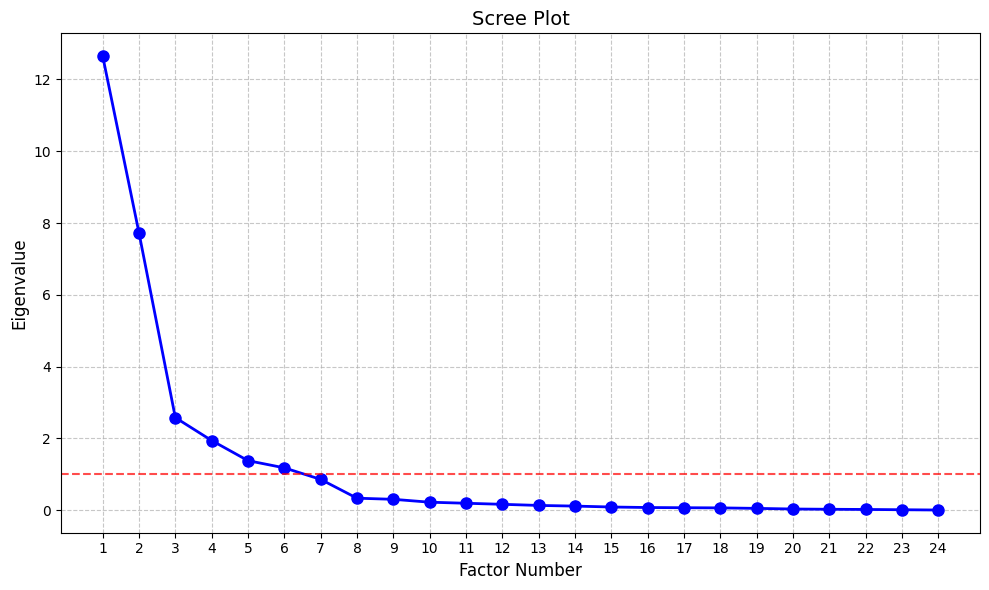

In [29]:
import matplotlib.pyplot as plt

# Look at a so-called scree plot to decide how many factors we need
plt.figure(figsize=(10, 6))

# Plot points and line for eigenvalues
# b = blue colour, o = circles
plt.plot(range(1, len(pca.explained_variance_) + 1),
         pca.explained_variance_, 'bo-', linewidth=2, markersize=8)

# Add a horizontal line at eigenvalue = 1
plt.axhline(y=1, color='r', linestyle='--', alpha=0.7)

# Customize labels and appearance
plt.xlabel('Factor Number', fontsize=12)
plt.ylabel('Eigenvalue', fontsize=12)
plt.title('Scree Plot', fontsize=14)
plt.xticks(range(1, len(pca.explained_variance_) + 1))
plt.grid(True, linestyle='--', alpha=0.7)

# Display the plot
plt.tight_layout()
plt.show()

**Communalities**: For our example in corpus linguistic, communalities reveal which linguistic features cluster together in meaningful ways across texts. When certain features have high communalities, these features pattern together in the data, suggesting they may reflect the same underlying linguistic dimension.

In [30]:
# This code calculate the so-called communalities
loadings = pca.components_.T
# Set the number of factors identified from the scree plot
n_factors = 4
# Calculate communalities (sum of squared loadings for each feature across retained factors)
communalities = np.sum(loadings[:, :n_factors]**2, axis=1)

# Create DataFrame of communalities
communalities_df = pd.DataFrame({
    'Feature': feature_names,
    'Communality': communalities
})

# Sort by communality value in descending order
communalities_df = communalities_df.sort_values('Communality', ascending=False)

print(communalities_df)

                               Feature  Communality
5                first_person_pronouns     0.834429
15         total_prepositional_phrases     0.811673
7   third_person_pronouns_excluding_it     0.799438
2                        present_tense     0.620483
0                           past_tense     0.531813
12                     nominalisations     0.164212
6               second_person_pronouns     0.126217
20                       private_verbs     0.037597
8                           pronoun_it     0.017119
11                         pro_verb_do     0.015400
1                              perfect     0.010904
21                       suasive_verbs     0.008622
9               demonstrative_pronouns     0.005860
14                             passive     0.005688
10                 indefinite_pronouns     0.003241
4                      time_adverbials     0.002143
13                             gerunds     0.001935
18           demonstrative_determiners     0.001334
3           

**Interpretation of communalities**:<br>
Features with High Communalities (>0.5) are well represented in the factors or dimensions, suggesting that the use of these features are a very important distinguishing characteristic across texts. These features patterns strongly with the identified factors.<br>
Features with Moderate Communalities (0.2-0.5) show moderate alignment with your factors. These features are partially captured by the factors but also have substantial unique variance not explained by the common factors.<br>
Features with Low Communalities (<0.1) indicating that these features vary independently of the main factors and might represent unique linguistic dimensions not captured by the current factor solution.

In [31]:
# Create a component matrix showing loadings of features on each factor
# Only include components with eigenvalues > 1
n_factors = 4
loadings = pca.components_.T[:, :n_factors]

# Create DataFrame for component matrix
component_matrix = pd.DataFrame(
    loadings,
    columns=[f'Factor {i+1}' for i in range(n_factors)],
    index=feature_names
)

# Round values for cleaner display
component_matrix = component_matrix.round(3)

print("\nComponent Matrix:")
print("Loadings of features on each factor")
print(component_matrix)


Component Matrix:
Loadings of features on each factor
                                    Factor 1  Factor 2  Factor 3  Factor 4
past_tense                          0.707000 -0.080000 -0.147000  0.063000
perfect                             0.084000  0.002000  0.042000  0.046000
present_tense                      -0.494000 -0.409000  0.356000  0.287000
place_adverbials                    0.018000  0.021000  0.012000 -0.008000
time_adverbials                     0.032000 -0.012000  0.013000  0.028000
first_person_pronouns               0.106000 -0.389000 -0.461000  0.678000
second_person_pronouns             -0.135000 -0.313000  0.091000 -0.040000
third_person_pronouns_excluding_it  0.454000 -0.306000  0.707000 -0.005000
pronoun_it                         -0.002000 -0.116000  0.012000  0.060000
demonstrative_pronouns             -0.010000 -0.053000  0.009000  0.054000
indefinite_pronouns                 0.013000 -0.046000  0.004000  0.031000
pro_verb_do                         0.011000 

In [33]:
# Finally, build the rotated component matrix
# apply Varimax rotation from factor_analyzer
!pip install factor_analyzer

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 1.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for factor_analyzer: filename=factor_analyzer-0.5.1-py2.py3-none-any.whl size=42655 sha256=7389cd566b8dc50b5cfd9c4c5976cd654014231aa8b5ca13243691e9ad19864c
  Stored in directory: /root/.cache/pip/wheels/a2/af/06/f4d4ed4d9d714fda437fb1583629417319603c2266e7b233cc
Successfully built factor_analyzer


In [34]:

from factor_analyzer.rotator import Rotator

# Use the existing factor loadings from above
# loadings = pca.components_.T[:, :n_factors]

# Perform Varimax rotation
rotator = Rotator()
# returns a numpy array by default
rotated_loadings = rotator.fit_transform(loadings)

# Create rotated component matrix
rotated_component_matrix = pd.DataFrame(
    rotated_loadings,
    columns=[f'Factor {i+1}' for i in range(n_factors)],
    index=feature_names
).round(3)

print("\nRotated Component Matrix (Varimax):")
print(rotated_component_matrix)



Rotated Component Matrix (Varimax):
                                    Factor 1  Factor 2  Factor 3  Factor 4
past_tense                          0.572000 -0.196000  0.391000  0.113000
perfect                             0.030000  0.011000  0.097000  0.023000
present_tense                      -0.665000  0.015000 -0.037000  0.420000
place_adverbials                    0.009000  0.006000  0.020000 -0.022000
time_adverbials                     0.012000  0.001000  0.037000  0.025000
first_person_pronouns               0.330000  0.112000 -0.116000  0.836000
second_person_pronouns             -0.226000 -0.219000 -0.045000  0.158000
third_person_pronouns_excluding_it -0.244000 -0.324000  0.795000  0.056000
pronoun_it                         -0.033000 -0.046000  0.017000  0.117000
demonstrative_pronouns             -0.023000 -0.002000  0.010000  0.072000
indefinite_pronouns                -0.003000 -0.017000  0.017000  0.052000
pro_verb_do                        -0.015000 -0.039000  0.02000

See Biber (1988: chapter 5, page 86, Table 5.3).<br>
We can now assign a feature to the factor for which it has the greatest positive loading.

---

**Exercise**: Which features should we assign to Factor 1 and 2 based on the Rotated Component Matrix above? As a rule of thumb, choose a cut-off point of 0.2 in absolute value.

In [35]:
# Examples indicated

factor_1_features = ['present_tense', 'past_tense', 'first_person_pronouns']
factor_2_features = ['nominalisations', 'private_verbs']
factor_3_features = ['first_person_pronouns', 'total_prepositional_phrases']

---



The factors can then be interpreted. They may reflect an underlying reason for the feature distribtuion in the text. This is a challenging and subjective task that must be done carefully.<br>
See Biber (1988: chapter 6, page 104).<br>
We can now calculate Factor scores for every texts using the features that were identifed as central for a factor.<br>
See Biber (1988: chapter 5, page 93-94)

In [36]:
# Standardize the dataframe
df_standardised = (df - df.mean()) / df.std()

pd.set_option('display.max_columns', 20)  # Show 20 columns
print(df_standardised)

      past_tense   perfect  present_tense  place_adverbials  time_adverbials  first_person_pronouns  second_person_pronouns  third_person_pronouns_excluding_it  pronoun_it  demonstrative_pronouns  ...   passive  total_prepositional_phrases  downtoners  amplifiers  demonstrative_determiners  public_verbs  private_verbs  suasive_verbs  seem_appear  split_infinitive
0      -0.251386 -0.818181      -0.868912         -0.745739        -0.032040              -0.731704               -0.715507                           -1.014808   -1.272972               -0.421205  ...  0.579407                     1.118837    0.396415   -0.831524                  -0.112707     -0.029959      -0.865283      -0.587333    -0.697810         -0.392721
1      -1.298271 -1.342567       1.261413          0.071233        -1.106568              -0.837888               -0.379436                           -1.025039   -1.031338                0.209467  ...  0.988686                     0.927547    0.051238   -0.395996     

List the features that we want to assign to Factor 1 and 2.

In [37]:
# Sum the z-scored absolute values (i,e. ignore the minus signs) for the features for each text
factor_1_scores = df_standardised[factor_1_features].abs().sum(axis=1)
factor_2_scores = df_standardised[factor_2_features].abs().sum(axis=1)
factor_3_scores = df_standardised[factor_3_features].abs().sum(axis=1)

# Combine into a single DataFrame
factor_scores = pd.DataFrame({
    'Factor 1': factor_1_scores,
    'Factor 2': factor_2_scores,
    'Factor 3': factor_3_scores
})

print(factor_scores)


      Factor 1  Factor 2  Factor 3
0     1.852002  3.227065  1.850541
1     3.397572  2.178420  1.765435
2     1.145158  0.759698  1.188076
3     2.241226  4.739071  1.592903
4     1.621405  1.325262  1.202911
...        ...       ...       ...
1289  3.057623  1.901755  2.189650
1290  3.571112  1.986853  2.442076
1291  3.529030  2.090579  3.453230
1292  1.205216  0.976823  0.779362
1293  0.771345  0.966544  1.140443

[1294 rows x 3 columns]


**We have thus reduced many dimensions into a small number of dimensions!**



---



**Part 4**: Clustering

Remember the data frame for the four files from the beginning of the lecture

In [38]:
print(df)

      past_tense  perfect  present_tense  place_adverbials  time_adverbials  first_person_pronouns  second_person_pronouns  third_person_pronouns_excluding_it  pronoun_it  demonstrative_pronouns  ...  passive  total_prepositional_phrases  downtoners  amplifiers  demonstrative_determiners  public_verbs  private_verbs  suasive_verbs  seem_appear  split_infinitive
0       3.143713 0.269461       3.233533          0.209581         0.449102               0.179641                0.000000                            0.269461    0.149701                0.419162  ... 0.868263                    12.305389    0.239521    0.000000                   0.508982      0.269461       0.688623       0.479042     0.000000          0.000000
1       0.411692 0.000000       8.069164          0.596953         0.123508               0.000000                0.473446                            0.247015    0.288184                0.658707  ... 1.049815                    11.939070    0.185261    0.061754           

The below shows HCA

In [39]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Select only numeric columns
X = df[['fstr', 'past', 'sent', 'long']]

# Standardise: mean=0, std=1 for each variable
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Perform hierarchical clustering on standardised data
Z = linkage(X_scaled, method='ward')

# Plot dendrogram
plt.figure(figsize=(8, 5))
dendrogram(Z, labels=df['filename'].values)
plt.title('Hierarchical Clustering')
plt.xlabel('Text')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

KeyError: "None of [Index(['fstr', 'past', 'sent', 'long'], dtype='object')] are in the [columns]"

Reduced dimensions (Factor analysis in the Biber toy example) can be used for clustering. For example, using k-means clustering.

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np

# Determine the optimal number of clusters using the elbow method
# The elbow method helps find the ideal number of clusters by measuring
# how adding more clusters improves the model's fit to the data
# So-called "inertia" measures how spread out points are within their clusters (lower = tighter clusters)
# As you add more clusters, the "inertia" will always decrease (points get closer to their centers),
# but the rate of improvement typically slows after a certain point.
# The "elbow point" is where adding another cluster doesn't improve the model as much as before.
# It appears as a bend in the curve (like an elbow) and represents the best trade-off
# between having few clusters and having low inertia.

# Create an empty list to store the "inertia" values for different numbers of clusters
inertia = []

# Test clustering with 1 through 9 clusters
k_range = range(1, 10)

# For each potential number of clusters (k):
for k in k_range:
   # Create a k-means model with k clusters
   # random_state=42 ensures reproducibility of results
   # n_init=10 means the algorithm runs 10 times with different starting points
   # and keeps the best result (helps avoid suboptimal solutions)
   kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

   # Fit the model to the factor scores data (performs the clustering)
   kmeans.fit(factor_scores[['Factor 1', 'Factor 2', 'Factor 3']])

   # Store the inertia
   # Lower inertia means points are closer to their cluster centers
   inertia.append(kmeans.inertia_)

# Plot the elbow curve to visualize how inertia changes with different k values
plt.figure(figsize=(10, 6))  # Set figure size

# Plot the number of clusters vs. inertia
# 'bo-' creates a blue line with circle markers
plt.plot(k_range, inertia, 'bo-')

# Add labels and title
plt.xlabel('Number of clusters')
plt.ylabel('Inertia (within-cluster sum of squares)')
plt.title('Elbow Method For Optimal k')

# Add grid lines for easier reading
plt.grid(True)

# Display the plot
plt.show()

In [ ]:


# Choose a number of clusters based on the elbow curve (example: k=4)
k = 3

# Create a KMeans clustering model with the following parameters:
# - n_clusters=k: Sets the number of clusters to create, we just determined k
# - random_state=42: Sets a fixed random seed for reproduction
# - n_init=10: Runs the algorithm 10 times with different centroid initializations
#  this helps to avoid local optima
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

# The fit_predict method does two operations in one:
# 1. Fits the KMeans model to our factor_scores data (determining cluster centers)
# 2. Predicts which cluster each text belongs to
# It returns an array of integers (0, 1, 2, etc.) representing the cluster assignment
# for each text, i.e. for each row in the factor_scores
clusters = kmeans.fit_predict(factor_scores[['Factor 1', 'Factor 2', 'Factor 3']])

print(clusters)


In [ ]:
# Add the cluster labels to the factor scores dataframe
factor_scores['Cluster'] = clusters
print(factor_scores)

In [ ]:
print(text_ids)

In [ ]:
print(text_feature_counts)

In [ ]:
# Add the genres as well

genres = []
for text_id in text_ids:
  for key, vals in text_feature_counts.items():
    if key == text_id:
      genres.append(text_feature_counts[text_id]['genre'])

factor_scores['Genre'] = genres

print(factor_scores)

In [ ]:
# Do not worry about this code
# We will make our plots later in R
# This is just an illustation

import matplotlib.pyplot as plt
import numpy as np

# Create a plot showing Factor 1 vs Factor 2
plt.figure(figsize=(12, 8))

# Get unique clusters and genres
unique_clusters = factor_scores['Cluster'].unique()
unique_genres = factor_scores['Genre'].unique()

# Define markers for each genre
markers = ['o', 's', '^', 'P']


# Define colors for clusters
colors = ['blue', 'red', 'green', 'purple', 'orange', 'brown']

# Plot each genre within each cluster
for i, cluster in enumerate(unique_clusters):
    for j, genre in enumerate(unique_genres):
        # Get data points for this combination of cluster and genre
        mask = (factor_scores['Cluster'] == cluster) & (factor_scores['Genre'] == genre)
        if mask.any():
            plt.scatter(
                factor_scores.loc[mask, 'Factor 1'],
                factor_scores.loc[mask, 'Factor 2'],
                s=80,
                c=colors[i % len(colors)],
                marker=markers[j % len(markers)],
                label=f'Cluster {cluster+1} - {genre}',
                alpha=0.7
            )

# Add labels and title
plt.xlabel('Factor 1', fontsize=12)
plt.ylabel('Factor 2', fontsize=12)
plt.title("Clusters based on toy versions of Biber's Factors", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)

# Create a legend

cluster_handles = [plt.Line2D([0], [0], marker='o', color=colors[i % len(colors)],
                  label=f'Cluster {cluster+1}', markersize=10, linestyle='None')
                  for i, cluster in enumerate(unique_clusters)]

genre_handles = [plt.Line2D([0], [0], marker=markers[j % len(markers)], color='black',
                    label=genre, markersize=10, linestyle='None')
                    for j, genre in enumerate(unique_genres)]

first_legend = plt.legend(handles=cluster_handles, title="Clusters",
                          bbox_to_anchor=(1.01, 1), loc='upper left')
plt.gca().add_artist(first_legend)

plt.legend(handles=genre_handles, title="Genres",
          bbox_to_anchor=(1.05, 0.7), loc='upper left')

plt.tight_layout()
plt.show()